In [10]:
# import packages needed 
!pip install biopython
import pandas as pd
from Bio import SeqIO 
from collections import Counter

# create dictionaries from frequencies in swissprot
swissprot_comp={ "L": 9.65,
    "A": 8.26,
    "G": 7.07,
    "V": 6.86,
    "E": 6.72,
    "S": 6.66,
    "I": 5.91,
    "K": 5.80,
    "R": 5.53,
    "D": 5.46,
    "T": 5.37,
    "P": 4.75,
    "N": 4.06,
    "Q": 3.93,
    "F": 3.87,
    "Y": 2.92,
    "M": 2.41,
    "H": 2.28,
    "C": 1.39,
    "W": 1.11}


In [12]:
# open positive fasta file
fasta_file= "pos_cluster-results_rep_seq.fasta"

#open positive training and benchmarkiing tsv files
pos_tr= pd.read_csv("positive_train.tsv", sep= '\t')
pos_bench = pd.read_csv("positive_benchmark.tsv", sep= '\t')

# create a dictionary from the tsv files with only the UniprotAccession and SP position informations
df_tr= pos_tr[["UniprotAccession", "SPPosition"]]
df_bh = pos_bench[["UniprotAccession", "SPPosition"]]

# map the dictionaries
sp_mapping_tr = dict(zip(df_tr["UniprotAccession"], df_tr["SPPosition"]))
sp_mapping_bh = dict(zip(df_bh["UniprotAccession"], df_bh["SPPosition"]))

In [331]:
# extract sp sequences from the training set
def cutting_tr(fasta_file, sp_mapping_tr):
    sp_list_tr= []
    for record in SeqIO.parse(fasta_file, 'fasta'):
        id= record.id
        if id in sp_mapping_tr:
            sp_pos= int(sp_mapping_tr[record.id])
            sp_seq = str(record.seq)[:sp_pos]
            sp_list_tr.append(sp_seq)
    return (sp_list_tr)

sp_list_tr = cutting_tr(fasta_file, sp_mapping_tr)
all_sp_tr = "".join(sp_list_tr) 

# using the function Counter to count the amino acids present in the SP position for training
counts_tr = Counter(all_sp_tr)

# extract sp sequences from the benchmark (or testing) set
def cutting_bh(fasta_file, sp_mapping_bh):
    sp_list_bh= []
    for record in SeqIO.parse(fasta_file, 'fasta'):
        id= record.id
        if id in sp_mapping_bh:
            sp_pos= int(sp_mapping_bh[record.id])
            sp_seq = str(record.seq)[:sp_pos]
            sp_list_bh.append(sp_seq)
    return (sp_list_bh)

sp_list_bh = cutting_bh(fasta_file, sp_mapping_bh)
all_sp_bh = "".join(sp_list_bh) 

#using the function Counter to count the amino acids present in the SP position for benchmark
counts_bh = Counter(all_sp_bh)       

...


In [310]:
# counting the aa frequencies of the SP train set
def count_total_frequencies(counts_tr):
    sum(counts.values())
    freq={}
    for aa, num in counts_tr.items():
        freq[aa]= round(num/total*100, 2)
    return (freq)
frequencies_tr= count_total_frequencies(counts_tr)

# counting the aa frequencies of the SP benchmarking set
def count_total_frequencies(counts_bh):
    sum(counts.values())
    freq={}
    for aa, num in counts_bh.items():
        freq[aa]= round(num/total*100, 2)
    return (freq)
frequencies_bh= count_total_frequencies(counts_bh)

In [311]:
# creating 3 dataframes with Swissprot and SP train and test sets frequencies 
counts_tr = clean_counts(counts_tr)
counts_bh = clean_counts(counts_bh)

df_tr = pd.DataFrame(list(frequencies_tr.items()), columns=["AA", "SP"])
df_bh= pd.DataFrame(list(frequencies_bh.items()), columns=["AA", "SP"])
df_swiss = pd.DataFrame(list(swissprot_comp.items()), columns=["AA", "SwissProt"])

df_tr["Source"] = "Training"
df_bh["Source"] = "Benchmark"

df_swiss = df_swiss.rename(columns={"SwissProt": "SP"})
df_swiss["Source"] = "SwissProt"

# combine
all_info = pd.concat([df_tr, df_bh, df_swiss], ignore_index=True)


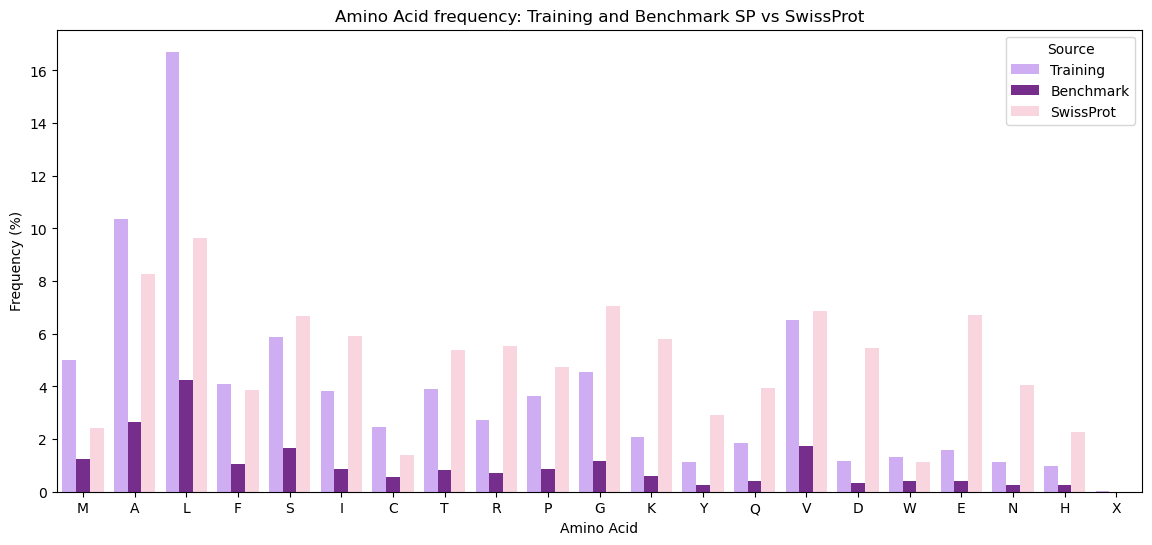

In [312]:
# bar plot of AA frequencies compairing the training set and the benchmark set with Swissprot. 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
custom_palette = ["#cea2fd", "#7e1e9c", "#ffcfdc"]
sns.barplot(data=all_info, x="AA", y="SP", hue="Source", palette= custom_palette)

plt.title("Amino Acid frequency: Training and Benchmark SP vs SwissProt")
plt.ylabel("Frequency (%)")
plt.xlabel("Amino Acid")
plt.legend(title="Source")
plt.savefig("AA_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


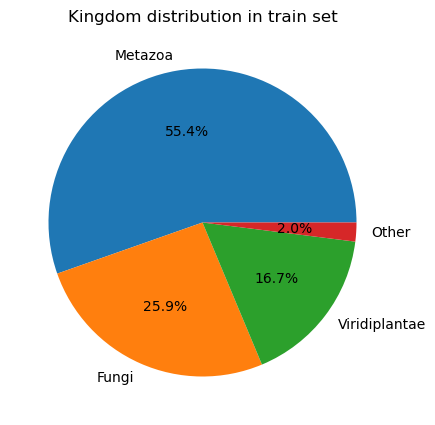

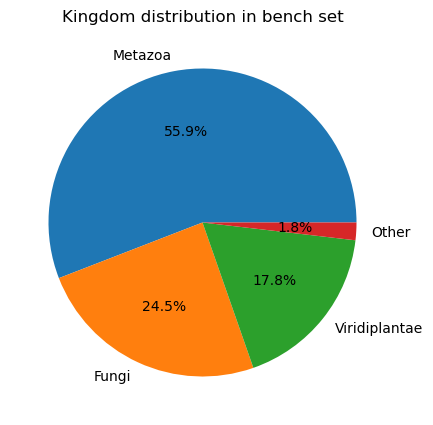

In [313]:
# Taxonomic classification (at kingdom and species levels)

import matplotlib.pyplot as plt
import seaborn as sns

data_species= pd.read_csv("all.tsv", sep= '\t')

# Count Kingdoms per Set 
kingdom_counts = data_species.groupby("Set")["Kingdom"].value_counts().reset_index(name="Count")

# make pie chart
for set_type in data_species["Set"].unique():
    subset = data_species[data_species["Set"] == set_type]
    counts = subset["Kingdom"].value_counts()

    plt.figure(figsize=(5,5))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"Kingdom distribution in {set_type} set")
    
    # change set_type so it’s safe for filenames
    safe_name = set_type.strip().replace(" ", "_")
    plt.savefig(f"Kingdom_dist_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


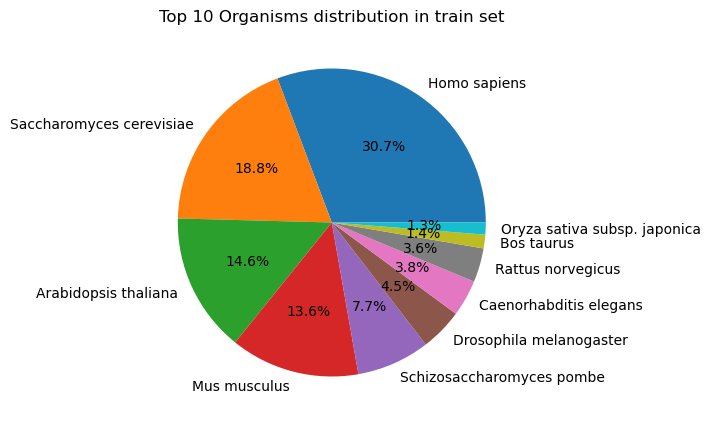

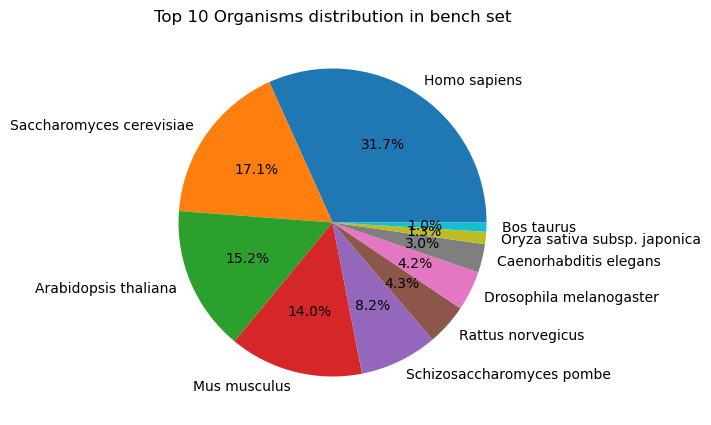

In [314]:
# create pie chart of top 10 organisms in training and benchmarking set 
for set_type in data_species["Set"].unique():
    subset = data_species[data_species["Set"] == set_type]
    counts = subset["Organism"].value_counts().nlargest(10)

    plt.figure(figsize=(5,5))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"Top 10 Organisms distribution in {set_type} set")

    #clear set type
    safe_name = set_type.strip().replace(" ", "_")
    plt.savefig(f"organism_dist_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
def extract_cleavage_motifs(fasta_file, sp_mapping, window_up=13, window_down=2):
   

    motifs = []
    
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id not in sp_mapping:
            continue
        
        seq = str(record.seq)
        spp = int(sp_mapping[record.id])          # 1-based
        
        # convert to 0-based python positions
        cleavage = spp - 1                        # −1 position index
        
        start = cleavage - window_up              
        end   = cleavage + window_down + 1        # +1 because python 
        
        # ensure sequence is long enough
        if start < 0 or end > len(seq):
            continue
        
        motif = seq[start:end]
        motifs.append(motif)
    
    return motifs


seqs_tr = extract_cleavage_motifs(fasta_file, sp_mapping_tr)

with open("motifs_tr_good.fasta", "w") as out:
    for i, m in enumerate(seqs_tr, 1):
        out.write(f">motif_{i}\n{m}\n")


In [15]:
# Extract cleavage-site motifs (-13 to +2) from the BENCHMARK positives only
def cutting_bh_motif(fasta_file, sp_mapping_bh):
    motifs_bh = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id in sp_mapping_bh:      # Only positives
            cut_pos = int(sp_mapping_bh[record.id])
            seq = str(record.seq)

            # extract the window only if sequence is long enough
            if cut_pos >= 13 and cut_pos + 2 <= len(seq):
                motif = seq[cut_pos-13 : cut_pos+2]
                motifs_bh.append(motif)

    return motifs_bh


# Run benchmark motif extraction
seqs_bh = cutting_bh_motif(fasta_file, sp_mapping_bh)

# Save to FASTA
with open("motifs_bh_right.fasta", "w") as out:
    for i, motif in enumerate(seqs_bh, 1):
        out.write(f">motif_{i}\n{motif}\n")
